In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
from pathlib import Path
import sys
import pandas as pd
import matplotlib.pyplot as plt

# ===== 1. Make repo importable =====
# 假设 notebook 在: CS50-analysis/tests/Harmonic_pattern_demo.ipynb
REPO_ROOT = Path.cwd().resolve().parents[0]
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

print("REPO_ROOT =", REPO_ROOT)

from stock_analysis.config import SLD_WINDOW_CONFIG

REPO_ROOT = C:\Users\17866\OneDrive\桌面\Ltq\2026a\data5703\project\work\current_work\CS50-analysis


## Import the data

In [2]:
# path
data_path = REPO_ROOT / "TestData" / "stock_1min_OHLC_long15.csv"


df = pd.read_csv(data_path)
print(df.head())

                    Datetime Ticker        Open        High         Low  \
0  2026-03-05 14:30:00+00:00   AAPL  260.744995  261.450012  259.160004   
1  2026-03-05 14:45:00+00:00   AAPL  259.339996  260.029999  258.859985   
2  2026-03-05 15:00:00+00:00   AAPL  259.910004  260.284485  258.579987   
3  2026-03-05 15:15:00+00:00   AAPL  259.619995  259.670013  258.540009   
4  2026-03-05 15:30:00+00:00   AAPL  258.910004  260.350006  258.075012   

        Close  
0  259.339905  
1  259.940002  
2  259.619995  
3  258.869995  
4  260.151306  


In [3]:
df_aapl = df[df["Ticker"] == "AAPL"].copy()
df_aapl = df_aapl.sort_values("Datetime").reset_index(drop=True)
print(df_aapl.shape)
df_aapl.head()

(1066, 6)


,Datetime,Ticker,Open,High,Low,Close
0,2026-03-05 14:30:00+00:00,AAPL,260.744995,261.450012,259.160004,259.339905
1,2026-03-05 14:45:00+00:00,AAPL,259.339996,260.029999,258.859985,259.940002
2,2026-03-05 15:00:00+00:00,AAPL,259.910004,260.284485,258.579987,259.619995
3,2026-03-05 15:15:00+00:00,AAPL,259.619995,259.670013,258.540009,258.869995
4,2026-03-05 15:30:00+00:00,AAPL,258.910004,260.350006,258.075012,260.151306


## Candlestick pattern Detector

In [4]:
import pkgutil
import importlib
import inspect
import pandas as pd
import numpy as np

from stock_analysis.base import BasePattern
import stock_analysis.candlestick_patterns as candle_pkg
from stock_analysis.context_scores.candlestick_score import candlestick_score

In [5]:
def load_candlestick_detectors():
    detectors = []

    for _, module_name, _ in pkgutil.iter_modules(candle_pkg.__path__):
        full_module_name = f"{candle_pkg.__name__}.{module_name}"
        module = importlib.import_module(full_module_name)

        for _, obj in inspect.getmembers(module, inspect.isclass):
            if issubclass(obj, BasePattern) and obj is not BasePattern:
                if getattr(obj, "enabled", False):
                    try:
                        detectors.append(obj())
                    except Exception as e:
                        print(f"Skip detector {obj.__name__}: {e}")

    return detectors


candlestick_detectors = load_candlestick_detectors()

print(f"Loaded {len(candlestick_detectors)} candlestick detectors:")
for d in candlestick_detectors:
    print("-", d.__class__.__name__)

Loaded 11 candlestick detectors:
- BearishEngulfingCandlestickPattern
- BearishHaramiCandlestickPattern
- BullishEngulfingCandlestickPattern
- BullishHaramiCandlestickPattern
- DojiCandlestickPattern
- EveningStarCandlestickPattern
- HammerCandlestickPattern
- InvertedHammerCandlestickPattern
- MorningStarCandlestickPattern
- ShootingStarCandlestickPattern
- SpinningTopCandlestickPattern


In [6]:
def run_detector(detector, df_window: pd.DataFrame) -> dict | None:
    try:
        if hasattr(detector, "_run"):
            result = detector._run(df_window)
        elif hasattr(detector, "run"):
            result = detector.run(df_window)
        else:
            return None

        if not isinstance(result, dict):
            return None

        return result

    except Exception:
        return None

In [7]:
CANDLESTICK_PATTERN_WINDOW_SIZE = {
    "DojiCandlestickPattern": 1,
    "HammerCandlestickPattern": 1,
    "InvertedHammerCandlestickPattern": 1,
    "ShootingStarCandlestickPattern": 1,
    "SpinningTopCandlestickPattern": 1,

    "BullishEngulfingCandlestickPattern": 2,
    "BearishEngulfingCandlestickPattern": 2,
    "BullishHaramiCandlestickPattern": 2,
    "BearishHaramiCandlestickPattern": 2,

    "MorningStarCandlestickPattern": 3,
    "EveningStarCandlestickPattern": 3,
}


CANDLESTICK_PATTERN_DIRECTION = {
    "BullishEngulfingCandlestickPattern": "bullish",
    "BearishEngulfingCandlestickPattern": "bearish",

    "BullishHaramiCandlestickPattern": "bullish",
    "BearishHaramiCandlestickPattern": "bearish",

    "MorningStarCandlestickPattern": "bullish",
    "EveningStarCandlestickPattern": "bearish",

    "HammerCandlestickPattern": "bullish",
    "InvertedHammerCandlestickPattern": "bullish",
    "ShootingStarCandlestickPattern": "bearish",

    "DojiCandlestickPattern": "neutral",
    "SpinningTopCandlestickPattern": "neutral",
}


def get_candlestick_direction(pattern_name: str, result: dict | None = None) -> str:
    if result and result.get("direction") in {"bullish", "bearish", "neutral"}:
        return result["direction"]

    return CANDLESTICK_PATTERN_DIRECTION.get(pattern_name, "neutral")

In [8]:
def is_valid_candlestick_signal(
    result: dict | None,
    pattern_name: str,
    min_confidence: float = 50,
) -> bool:
    if not result:
        return False

    if result.get("confidence", 0) < min_confidence:
        return False

    if not result.get("confirmed", False) and not result.get("structure_detected", False):
        return False

    direction = get_candlestick_direction(pattern_name, result)

    if direction not in {"bullish", "bearish"}:
        return False

    return True

formation

In [9]:
def collect_candlestick_formations_at_t(
    df_hist: pd.DataFrame,
    detectors: list,
    recent_windows_per_pattern: int = 5,
    min_confidence: float = 50,
    verbose: bool = False,
) -> list[dict]:

    formations = []

    for detector in detectors:
        pattern_name = detector.__class__.__name__
        window_size = CANDLESTICK_PATTERN_WINDOW_SIZE.get(pattern_name, 1)

        if len(df_hist) < window_size:
            continue

        for window_count in range(1, recent_windows_per_pattern + 1):
            end_idx = len(df_hist) - (window_count - 1)
            start_idx = end_idx - window_size

            if start_idx < 0:
                continue

            df_window = df_hist.iloc[start_idx:end_idx].reset_index(drop=True)
            result = run_detector(detector, df_window)

            if not is_valid_candlestick_signal(
                result=result,
                pattern_name=pattern_name,
                min_confidence=min_confidence,
            ):
                continue

            direction = get_candlestick_direction(pattern_name, result)

            formation = {
                "pattern": pattern_name,
                "confidence": result.get("confidence", 0),
                "window_count": window_count,
                "window_size": window_size,
                "signal": {
                    "direction": direction,
                    "pivots": result.get("pivots", []),
                },
                "raw_result": result,
            }

            formations.append(formation)

            if verbose:
                print(
                    f"[FOUND] {pattern_name} | "
                    f"window_size={window_size} | "
                    f"window_count={window_count} | "
                    f"confidence={formation['confidence']} | "
                    f"direction={direction}"
                )

    return formations

## Backtest

In [10]:
def backtest_candlestick_context_score(
    df: pd.DataFrame,
    detectors: list,
    min_history: int = 30,
    future_horizon: int = 5,
    recent_windows_per_pattern: int = 5,
    return_lookback: int = 5,
    min_confidence: float = 50,
) -> pd.DataFrame:

    records = []
    start_t = max(min_history, return_lookback)

    for t in range(start_t, len(df) - future_horizon):
        df_hist = df.iloc[:t + 1].copy()

        past_row = df.iloc[t - return_lookback]
        current_row = df.iloc[t]
        future_row = df.iloc[t + future_horizon]

        formations = collect_candlestick_formations_at_t(
            df_hist=df_hist,
            detectors=detectors,
            recent_windows_per_pattern=recent_windows_per_pattern,
            min_confidence=min_confidence,
        )

        ctx = candlestick_score(formations)

        past_close = past_row["Close"]
        current_close = current_row["Close"]
        future_close = future_row["Close"]

        recent_return = (current_close - past_close) / max(abs(past_close), 1e-9)
        future_return = (future_close - current_close) / max(abs(current_close), 1e-9)

        bias = ctx["bias"]

        if bias == "bullish":
            recent_correct = int(recent_return > 0)
            future_correct = int(future_return > 0)
        elif bias == "bearish":
            recent_correct = int(recent_return < 0)
            future_correct = int(future_return < 0)
        else:
            recent_correct = np.nan
            future_correct = np.nan

        records.append({
            "t": t,
            "Datetime": current_row["Datetime"],

            "score": ctx["score"],
            "bias": bias,
            "agreement": ctx["agreement"],
            "bull_score": ctx["bull_score"],
            "bear_score": ctx["bear_score"],
            "pattern_count": ctx["pattern_count"],

            "recent_return": recent_return,
            "future_return": future_return,

            "past_close": past_close,
            "current_close": current_close,
            "future_close": future_close,

            "recent_correct": recent_correct,
            "future_correct": future_correct,

            "formations": formations,
            "context_detail": ctx,
        })

    return pd.DataFrame(records)

In [11]:
tickers = [
    "AAPL", "MSFT", "NVDA", "TSLA", "GOOGL",
    "AMZN", "META", "JPM", "BAC", "GS"
]

In [12]:
all_results = []

for ticker in tickers:
    print(f"\nRunning chart backtest for {ticker}...")

    df_ticker = (
        df[df["Ticker"] == ticker]
        .copy()
        .sort_values("Datetime")
        .reset_index(drop=True)
    )

    if len(df_ticker) < 180:
        print(f"{ticker}: skipped, not enough data")
        continue

    try:
        result = backtest_candlestick_context_score(
            df=df_ticker,
            detectors=candlestick_detectors,
            min_history=390,
            future_horizon=78,
            recent_windows_per_pattern= 100,
            return_lookback=78,
        )

        if result.empty:
            print(f"{ticker}: empty result")
            continue

        result["Ticker"] = ticker
        all_results.append(result)

        print(f"{ticker}: done, rows = {len(result)}")

    except Exception as e:
        print(f"{ticker}: failed -> {e}")

candlestick_backtest_all = pd.concat(all_results, ignore_index=True)

print("\nAll backtest results:")
print(candlestick_backtest_all.shape)
candlestick_backtest_all.head()


Running chart backtest for AAPL...
AAPL: done, rows = 598

Running chart backtest for MSFT...
MSFT: done, rows = 598

Running chart backtest for NVDA...
NVDA: done, rows = 598

Running chart backtest for TSLA...
TSLA: done, rows = 598

Running chart backtest for GOOGL...
GOOGL: done, rows = 598

Running chart backtest for AMZN...
AMZN: done, rows = 598

Running chart backtest for META...
META: done, rows = 598

Running chart backtest for JPM...
JPM: done, rows = 598

Running chart backtest for BAC...
BAC: done, rows = 598

Running chart backtest for GS...
GS: done, rows = 598

All backtest results:
(5980, 18)


,t,Datetime,score,bias,agreement,bull_score,bear_score,pattern_count,recent_return,future_return,past_close,current_close,future_close,recent_correct,future_correct,formations,context_detail,Ticker
0,390,2026-03-26 13:30:00+00:00,0.0623,bullish,0.7779,0.6103,0.1743,15,-0.005724,-0.016041,253.309998,251.860001,247.820007,0.0,0.0,[{'pattern': 'BearishEngulfingCandlestickPatte...,"{'score': 0.0623, 'bias': 'bullish', 'agreemen...",AAPL
1,391,2026-03-26 13:45:00+00:00,0.0621,bullish,0.7779,0.6103,0.1743,15,0.006844,-0.019526,252.044998,253.770004,248.815002,1.0,0.0,[{'pattern': 'BearishEngulfingCandlestickPatte...,"{'score': 0.0621, 'bias': 'bullish', 'agreemen...",AAPL
2,392,2026-03-26 14:00:00+00:00,0.0620,bullish,0.7779,0.6103,0.1743,15,0.011541,-0.025642,252.139999,255.050003,248.509995,1.0,0.0,[{'pattern': 'BearishEngulfingCandlestickPatte...,"{'score': 0.062, 'bias': 'bullish', 'agreement...",AAPL
3,393,2026-03-26 14:15:00+00:00,0.0618,bullish,0.7779,0.6103,0.1743,15,0.013746,-0.027236,252.439896,255.910004,248.940094,1.0,0.0,[{'pattern': 'BearishEngulfingCandlestickPatte...,"{'score': 0.0618, 'bias': 'bullish', 'agreemen...",AAPL
4,394,2026-03-26 14:30:00+00:00,0.0610,bullish,0.7356,0.5885,0.2115,14,0.017702,-0.034320,251.949997,256.410004,247.610001,1.0,0.0,[{'pattern': 'BearishEngulfingCandlestickPatte...,"{'score': 0.061, 'bias': 'bullish', 'agreement...",AAPL


In [13]:
corr_records = []

for ticker, group in candlestick_backtest_all.groupby("Ticker"):
    temp = group[["score", "recent_return", "future_return"]].dropna()

    if len(temp) < 10:
        print(f"{ticker}: skipped correlation, too few valid rows")
        continue

    recent_corr = temp["score"].corr(temp["recent_return"])
    future_corr = temp["score"].corr(temp["future_return"])

    corr_records.append({
        "Ticker": ticker,
        "Recent_Return_Corr": recent_corr,
        "Future_Return_Corr": future_corr,
        "N": len(temp)
    })

corr_df = pd.DataFrame(corr_records)

print(corr_df)

  Ticker  Recent_Return_Corr  Future_Return_Corr    N
0   AAPL            0.414478           -0.389076  598
1   AMZN            0.511272            0.236064  598
2    BAC           -0.111068           -0.107898  598
3  GOOGL           -0.125860           -0.212658  598
4     GS            0.255788           -0.316432  598
5    JPM           -0.292433            0.244003  598
6   META            0.042067            0.216200  598
7   MSFT           -0.134515            0.383310  598
8   NVDA            0.158671           -0.049983  598
9   TSLA           -0.209108           -0.099729  598


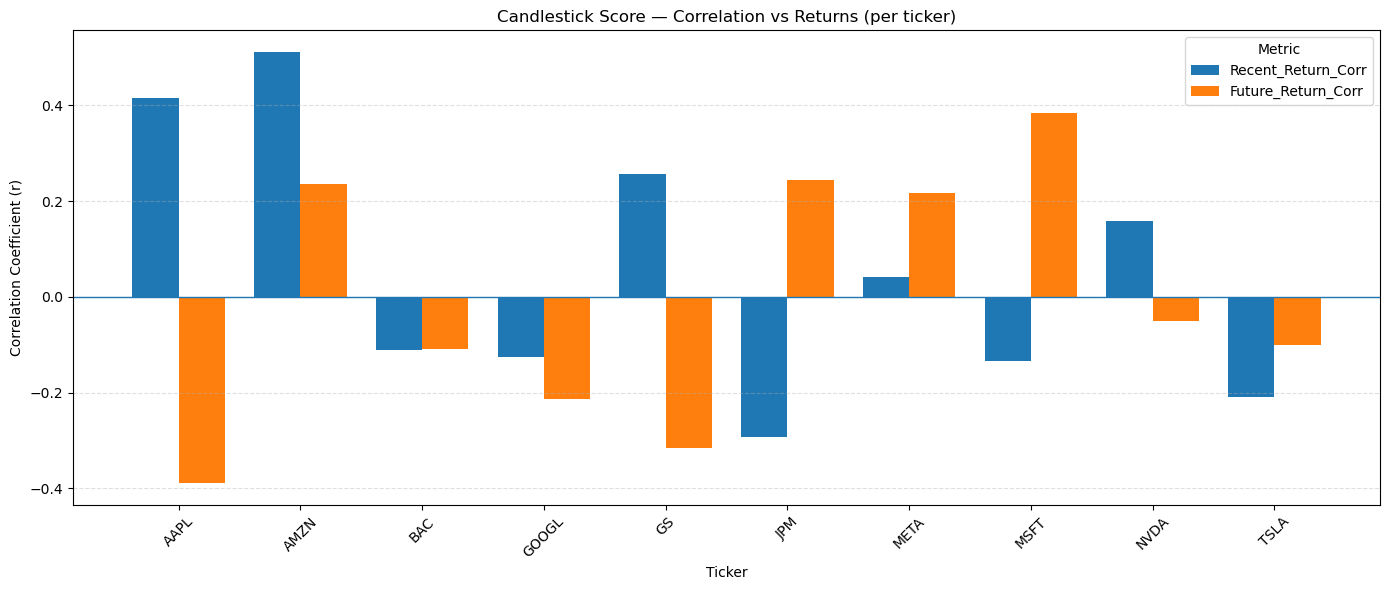

In [14]:
import matplotlib.pyplot as plt
import numpy as np

plot_df = corr_df.copy()
plot_df = plot_df.sort_values("Ticker").reset_index(drop=True)

x = np.arange(len(plot_df))
width = 0.38

plt.figure(figsize=(14, 6))

plt.bar(
    x - width / 2,
    plot_df["Recent_Return_Corr"],
    width,
    label="Recent_Return_Corr"
)

plt.bar(
    x + width / 2,
    plot_df["Future_Return_Corr"],
    width,
    label="Future_Return_Corr"
)

plt.axhline(0, linewidth=1)

plt.xticks(x, plot_df["Ticker"], rotation=45)
plt.ylabel("Correlation Coefficient (r)")
plt.xlabel("Ticker")
plt.title("Candlestick Score — Correlation vs Returns (per ticker)")
plt.legend(title="Metric")
plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

In [15]:
import pandas as pd
import numpy as np
from sklearn.metrics import f1_score, recall_score

metric_records = []

for ticker, group in candlestick_backtest_all.groupby("Ticker"):
    temp = group.copy()

    # 只保留有方向预测的 rows
    temp = temp[temp["bias"].isin(["bullish", "bearish"])].copy()

    if len(temp) < 10:
        print(f"{ticker}: skipped, too few directional rows")
        continue

    # ===== recent direction =====
    temp["recent_true"] = np.where(temp["recent_return"] > 0, 1, 0)
    temp["future_true"] = np.where(temp["future_return"] > 0, 1, 0)

    # bullish = 1, bearish = 0
    temp["pred"] = np.where(temp["bias"] == "bullish", 1, 0)

    metric_records.append({
        "Ticker": ticker,
        "Recent_F1": f1_score(temp["recent_true"], temp["pred"], zero_division=0),
        "Future_F1": f1_score(temp["future_true"], temp["pred"], zero_division=0),
        "Recent_Recall": recall_score(temp["recent_true"], temp["pred"], zero_division=0),
        "Future_Recall": recall_score(temp["future_true"], temp["pred"], zero_division=0),
        "N": len(temp),
    })

candlestick_metric_df = pd.DataFrame(metric_records)
candlestick_metric_df

,Ticker,Recent_F1,Future_F1,Recent_Recall,Future_Recall,N
0,AAPL,0.827381,0.761006,1.000000,1.000000,197
1,AMZN,0.649789,0.562092,0.509934,0.390909,257
2,BAC,0.892045,0.785047,0.963190,0.954545,195
3,GOOGL,0.000000,0.116071,0.000000,0.065327,232
4,GS,0.789238,0.614679,0.854369,0.683673,158
5,JPM,0.721893,0.727915,0.701149,0.865546,217
6,META,0.581560,0.790323,0.602941,0.960784,112
7,MSFT,0.537549,0.883212,0.531250,0.812081,204
8,NVDA,0.866171,0.777344,0.958848,0.917051,313
9,TSLA,0.702439,0.686420,1.000000,1.000000,266


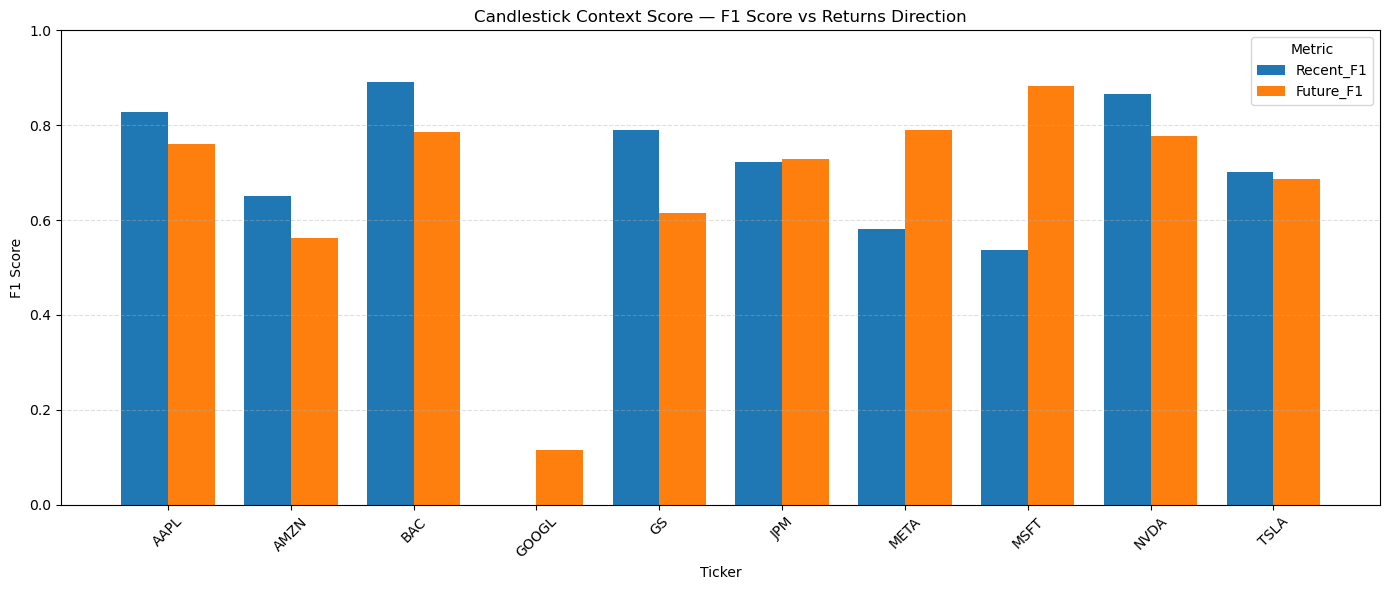

In [16]:
import matplotlib.pyplot as plt
import numpy as np

plot_df = candlestick_metric_df.sort_values("Ticker").reset_index(drop=True)

x = np.arange(len(plot_df))
width = 0.38

plt.figure(figsize=(14, 6))

plt.bar(
    x - width / 2,
    plot_df["Recent_F1"],
    width,
    label="Recent_F1"
)

plt.bar(
    x + width / 2,
    plot_df["Future_F1"],
    width,
    label="Future_F1"
)

plt.xticks(x, plot_df["Ticker"], rotation=45)
plt.ylabel("F1 Score")
plt.xlabel("Ticker")
plt.title("Candlestick Context Score — F1 Score vs Returns Direction")
plt.ylim(0, 1)
plt.legend(title="Metric")
plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

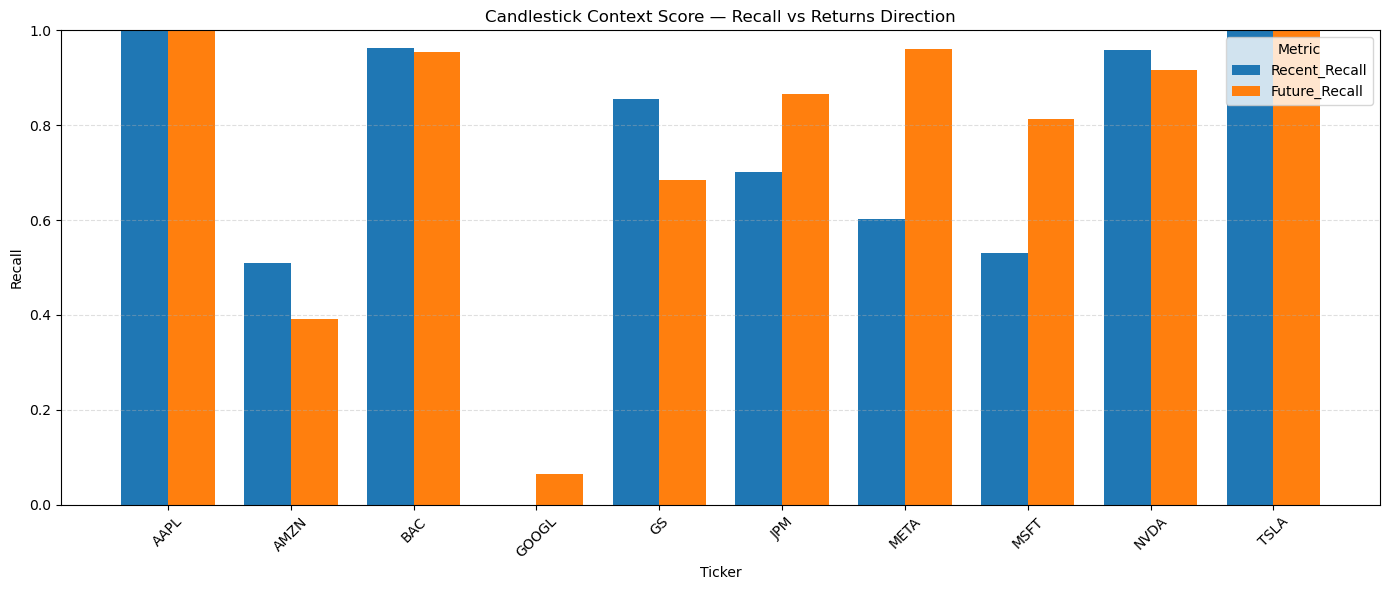

In [17]:
plot_df = candlestick_metric_df.sort_values("Ticker").reset_index(drop=True)

x = np.arange(len(plot_df))
width = 0.38

plt.figure(figsize=(14, 6))

plt.bar(
    x - width / 2,
    plot_df["Recent_Recall"],
    width,
    label="Recent_Recall"
)

plt.bar(
    x + width / 2,
    plot_df["Future_Recall"],
    width,
    label="Future_Recall"
)

plt.xticks(x, plot_df["Ticker"], rotation=45)
plt.ylabel("Recall")
plt.xlabel("Ticker")
plt.title("Candlestick Context Score — Recall vs Returns Direction")
plt.ylim(0, 1)
plt.legend(title="Metric")
plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

In [19]:
from sklearn.metrics import precision_score, accuracy_score, f1_score, recall_score
import numpy as np
import pandas as pd

extra_records = []

for ticker, group in candlestick_backtest_all.groupby("Ticker"):
    # ✅ 修复这里：用 group["bias"]，不是 temp["bias"]
    temp = group[group["bias"].isin(["bullish", "bearish"])].copy()

    if len(temp) < 10:
        print(f"{ticker}: skipped, too few directional rows")
        continue

    temp["recent_true"] = np.where(temp["recent_return"] > 0, 1, 0)
    temp["future_true"] = np.where(temp["future_return"] > 0, 1, 0)
    temp["pred"] = np.where(temp["bias"] == "bullish", 1, 0)

    extra_records.append({
        "Ticker": ticker,
        "Recent_Accuracy": accuracy_score(temp["recent_true"], temp["pred"]),
        "Future_Accuracy": accuracy_score(temp["future_true"], temp["pred"]),
        "Recent_Precision": precision_score(temp["recent_true"], temp["pred"], zero_division=0),
        "Future_Precision": precision_score(temp["future_true"], temp["pred"], zero_division=0),
        "Recent_F1": f1_score(temp["recent_true"], temp["pred"], zero_division=0),
        "Future_F1": f1_score(temp["future_true"], temp["pred"], zero_division=0),
        "Recent_Recall": recall_score(temp["recent_true"], temp["pred"], zero_division=0),
        "Future_Recall": recall_score(temp["future_true"], temp["pred"], zero_division=0),
        "N": len(temp),
    })

candlestick_full_metric_df = pd.DataFrame(extra_records)
candlestick_full_metric_df

,Ticker,Recent_Accuracy,Future_Accuracy,Recent_Precision,Future_Precision,Recent_F1,Future_F1,Recent_Recall,Future_Recall,N
0,AAPL,0.705584,0.614213,0.705584,0.614213,0.827381,0.761006,1.000000,1.000000,197
1,AMZN,0.677043,0.478599,0.895349,1.000000,0.649789,0.562092,0.509934,0.390909,257
2,BAC,0.805128,0.646154,0.830688,0.666667,0.892045,0.785047,0.963190,0.954545,195
3,GOOGL,0.202586,0.146552,0.000000,0.520000,0.000000,0.116071,0.000000,0.065327,232
4,GS,0.702532,0.468354,0.733333,0.558333,0.789238,0.614679,0.854369,0.683673,158
5,JPM,0.566820,0.645161,0.743902,0.628049,0.721893,0.727915,0.701149,0.865546,217
6,META,0.473214,0.767857,0.561644,0.671233,0.581560,0.790323,0.602941,0.960784,112
7,MSFT,0.426471,0.843137,0.544000,0.968000,0.537549,0.883212,0.531250,0.812081,204
8,NVDA,0.769968,0.635783,0.789831,0.674576,0.866171,0.777344,0.958848,0.917051,313
9,TSLA,0.541353,0.522556,0.541353,0.522556,0.702439,0.686420,1.000000,1.000000,266


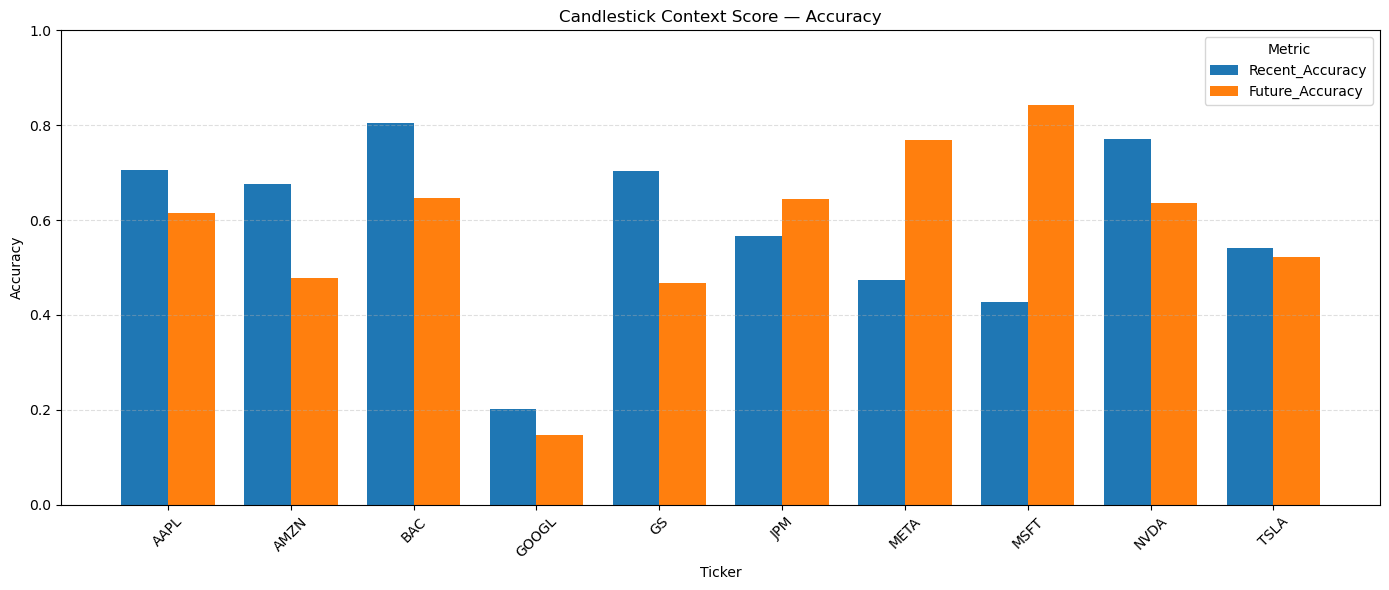

In [20]:
plot_df = candlestick_full_metric_df.sort_values("Ticker").reset_index(drop=True)

x = np.arange(len(plot_df))
width = 0.38

plt.figure(figsize=(14, 6))

plt.bar(
    x - width / 2,
    plot_df["Recent_Accuracy"],
    width,
    label="Recent_Accuracy"
)

plt.bar(
    x + width / 2,
    plot_df["Future_Accuracy"],
    width,
    label="Future_Accuracy"
)

plt.xticks(x, plot_df["Ticker"], rotation=45)
plt.ylabel("Accuracy")
plt.xlabel("Ticker")
plt.title("Candlestick Context Score — Accuracy")
plt.ylim(0, 1)

plt.legend(title="Metric")
plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

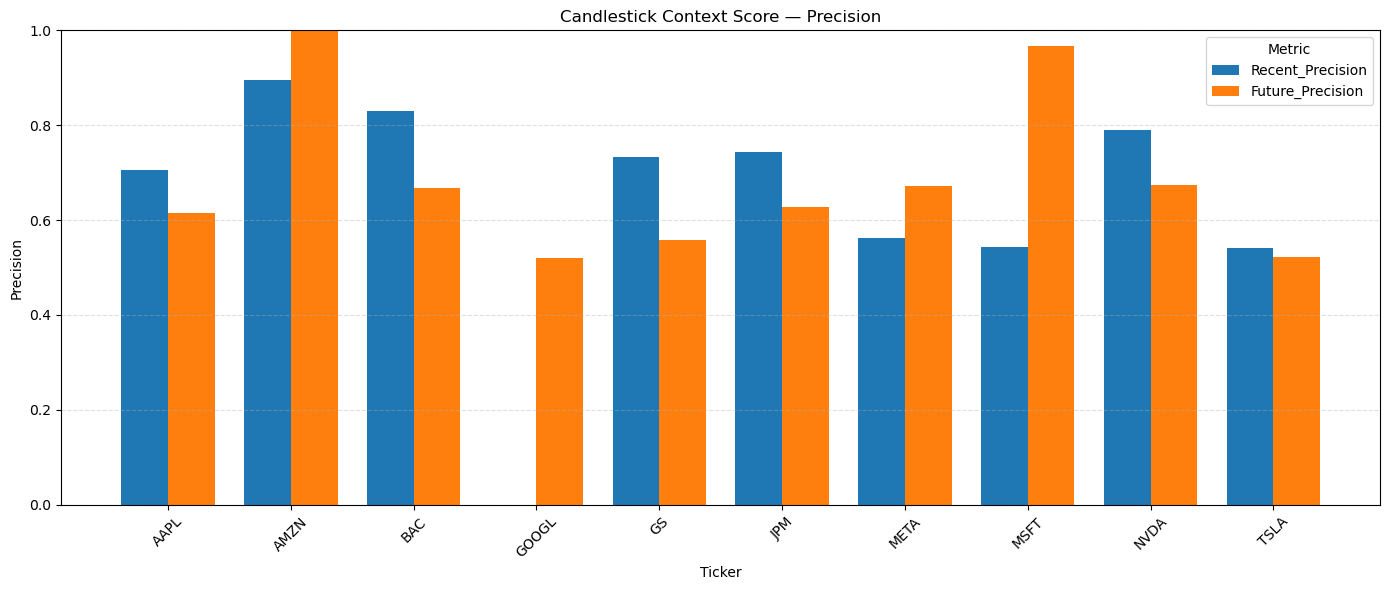

In [21]:
plot_df = candlestick_full_metric_df.sort_values("Ticker").reset_index(drop=True)

x = np.arange(len(plot_df))
width = 0.38

plt.figure(figsize=(14, 6))

plt.bar(
    x - width / 2,
    plot_df["Recent_Precision"],
    width,
    label="Recent_Precision"
)

plt.bar(
    x + width / 2,
    plot_df["Future_Precision"],
    width,
    label="Future_Precision"
)

plt.xticks(x, plot_df["Ticker"], rotation=45)
plt.ylabel("Precision")
plt.xlabel("Ticker")
plt.title("Candlestick Context Score — Precision")
plt.ylim(0, 1)

plt.legend(title="Metric")
plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()